# Expoloratory Data Analysis

This notebook documents the exploratory analysis of the CIC IIoT 2025 (DataSense) dataset in preparation for federated learning experiments. The dataset uses a 10-second aggregation window to match the baseline evaluations in the DataSense paper (Table 8, Figures 12–15).

In [2]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
#from IPython.display import set_matplotlib_formats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

#re-run this later
#set_matplotlib_formats('retina', quality=100)

print("Libraries loaded.")

Libraries loaded.


---

## Dataset Loading and Merging

The attack and benign 10-second CSVs were concatenated into a single dataframe so that every row has a label (attack type or Benign). This unified format is required for both the centralized baseline and the federated partitioning pipeline.

In [3]:
# Merging attack and benign dataset

attack_df = pd.read_csv("../data/raw/attack_samples_10sec.csv")
benign_df = pd.read_csv("../data/raw/benign_samples_10sec.csv")
df = pd.concat([attack_df, benign_df], ignore_index=True)
df.to_csv("../data/processed/datasense_10sec_combined.csv", index=False)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 30,030 rows × 94 columns


---

## Schema Overview

Document every column, its dtype, and identify which columns are numeric vs. object (string/list). The DataSense dataset contains ~84 features plus label columns. List-type columns (e.g., "Ports All", "IPs Dst") are stored as strings and will need special handling.

In [4]:
print("=== Column Names & Types ===\n")
col_info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count(),
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique()
})
display(col_info)

# Separate numeric vs. object columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Object columns:  {len(object_cols)}")
print(f"\nObject columns (likely list-type or labels):\n{object_cols}")

=== Column Names & Types ===



,dtype,non_null,null_count,null_pct,n_unique
device_name,str,30030,0,0.0,38
device_mac,str,30030,0,0.0,38
label_full,str,30030,0,0.0,937
label1,str,30030,0,0.0,2
label2,str,30030,0,0.0,8
...,...,...,...,...,...
network_ttl_std_deviation,float64,30030,0,0.0,12116
network_window-size_avg,float64,30030,0,0.0,12784
network_window-size_max,float64,30030,0,0.0,199
network_window-size_min,float64,30030,0,0.0,479



Numeric columns: 71
Object columns:  23

Object columns (likely list-type or labels):
['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3', 'label4', 'timestamp', 'timestamp_start', 'timestamp_end', 'log_data-types', 'network_ips_all', 'network_ips_dst', 'network_ips_src', 'network_macs_all', 'network_macs_dst', 'network_macs_src', 'network_ports_all', 'network_ports_dst', 'network_ports_src', 'network_protocols_all', 'network_protocols_dst', 'network_protocols_src']


---

## Label Columns

The dataset should have label columns for binary classification (Benign vs. Attack) and multi-class classification (8 categories: Benign, DDoS, DoS, Recon, MITM, Web, BruteForce, Malware). There may also be a fine-grained label with all 50 attack types.

In [5]:
for col in object_cols:
    if df[col].nunique() <= 100:  # label columns won't have thousands of unique values
        print(f"\n{col} — {df[col].nunique()} unique values:")
        print(df[col].value_counts().head(15))


device_name — 38 unique values:
device_name
edge1                   2037
mqtt-broker             2034
router                  1092
ap                       955
wisenet-camera           923
steam-sensor             892
weather-sensor           873
yi-camera                871
motion-sensor            870
light-sensor             822
water-sensor             822
gas-sensor               822
accelerometer-sensor     822
ultrasonic-sensor        822
sound-sensor             822
Name: count, dtype: int64

device_mac — 38 unique values:
device_mac
dc:a6:32:dc:27:d4    2037
dc:a6:32:dc:28:46    2034
28:87:ba:bd:c6:6c    1092
30:de:4b:e2:13:4e     955
00:09:18:6d:73:b9     923
08:b6:1f:81:d2:cc     892
08:b6:1f:82:12:30     873
7c:94:9f:84:71:7e     871
08:b6:1f:82:1c:3c     870
8c:aa:b5:8a:a9:b4     822
08:b6:1f:84:66:78     822
08:b6:1f:83:25:98     822
08:b6:1f:82:ee:44     822
08:b6:1f:82:ee:c4     822
f0:08:d1:ce:cf:c8     822
Name: count, dtype: int64

label1 — 2 unique values:
label1
a

By analyzing what value each label maps to, we can uncover the full label hierarchy:

- `label1` -> binary classification (attack/benign)
- `label2` -> 8-class classification of attack categories
- `label3` -> 50-class fine-grained label that has the specific attack name
- `label4` -> the attack category + attack name combined --- useful as a human-readable bridge between `label2` and `label3`
- `label_full` -> contains the full session descriptor including target devices --- useful for designing realistic non-IID partitions

| Attack Categories | No. of Attack Types | Attack Description |
| ----------------- | ------------------- | ------------------ |
| Reconnaissance | 9 | Host discovery, port scanning, OS fingerprinting, vulnerability scanning. These produced the most sensor log entries because they don't disrupt device operation. |
| DDoS | 15  | Coordinated floods from multiple bots: TCP SYN, UDP, ICMP, HTTP, ACK fragmentation, Slowloris, and others. Generated the highest packet volumes (~1.14 billion packets) |
| Dos  | 15  | Same flood techniques but from a single attacker (~538 million packets) |
| Man-in-the-Middle | 3  | ARP spoofing, IP spoofing, and device impersonation. |
| Web exploitation  | 5  | SQL injection, command injection, cross-site scripting, backdoor upload |
| Brute force | 2  | Dictionary attacks against SSH and Telnet services. |
| Malware | 2  | Actual Mirai botnet deployment with infection propagation followed by SYN flood and UDP flood attacks from compromised devices. |


In [6]:
# Set label variables

LABEL_COL        = "label2"         # 8-class — primary target
LABEL_COL_BINARY = "label1"         # binary classification
LABEL_COL_FINE   = "label3"         # ~50 individual attack types
LABEL_COL_DETAIL = "label4"         # category_attack 
LABEL_COL_FULL   = "label_full"     # full session descriptor
DEVICE_COL       = "device_name"    # device list

---

## Class Distribution

The DataSense paper claims a balanced mix of benign and malicious traffic. It is important to verify the exact ratios here because class imblance will be amplified under non-IID federated partitioning

=== Class Distribution ===


,count,percent
label2,,
benign,13680,45.55
recon,6005,20.00
dos,3280,10.92
ddos,3234,10.77
mitm,1471,4.90
malware,1444,4.81
web,552,1.84
bruteforce,364,1.21


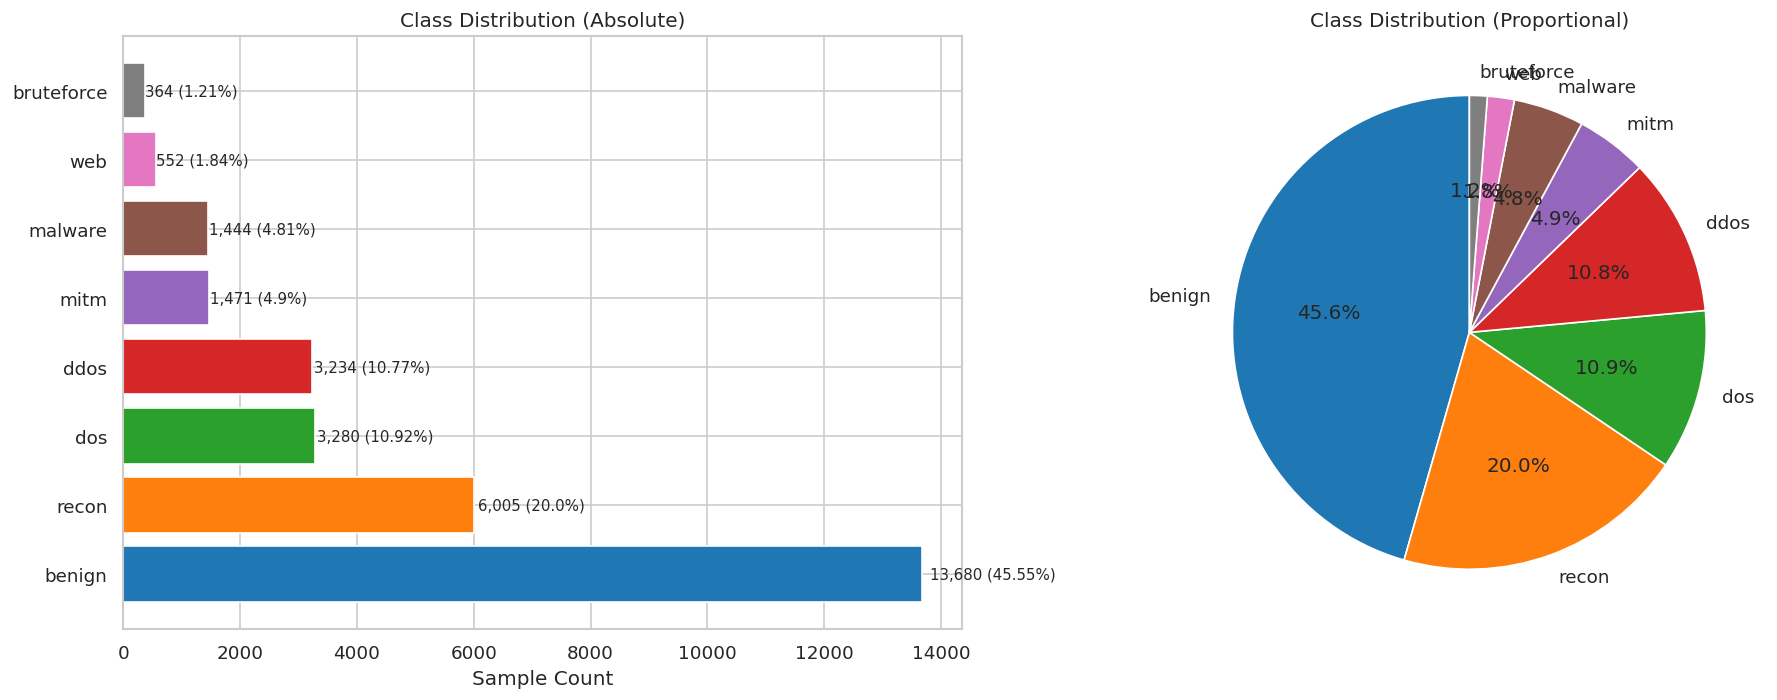


Expected 8 classes present: True
Actual unique labels: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']


In [7]:
class_counts = df[LABEL_COL].value_counts()
class_pcts = (class_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": class_counts, "percent": class_pcts})
print("=== Class Distribution ===")
display(summary)

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
axes[0].barh(class_counts.index, class_counts.values, color=sns.color_palette("tab10", len(class_counts)))
axes[0].set_xlabel("Sample Count")
axes[0].set_title("Class Distribution (Absolute)")
for i, (v, pct) in enumerate(zip(class_counts.values, class_pcts.values)):
    axes[0].text(v + v * 0.01, i, f"{v:,} ({pct}%)", va="center", fontsize=9)

# Percentage pie
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("tab10", len(class_counts)))
axes[1].set_title("Class Distribution (Proportional)")

plt.tight_layout()
plt.savefig("../results/eda_class_distribution.png", bbox_inches="tight")
plt.show()

# Check for the 8 expected categories
expected_classes = {"benign", "ddos", "dos", "recon", "mitm", "web", "bruteforce", "malware"}
actual_classes = set(df[LABEL_COL].unique())
print(f"\nExpected 8 classes present: {expected_classes.issubset(actual_classes)}")
print(f"Actual unique labels: {sorted(actual_classes)}")

---

## Missing Values & Data Quality

Check for NaN, infinite, and constant (zero-variance) columns. These values will be fed directly into `preprocessing.py`

In [8]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)
if len(missing_cols) == 0:
    print("No missing values found.")
else:
    print(f"{len(missing_cols)} columns with missing values:")
    display(pd.DataFrame({
        "null_count": missing_cols,
        "null_pct": (missing_cols / len(df) * 100).round(2)
    }))

# Check for infinite values in numeric columns
print("\n=== Infinite Values ===")
inf_counts = {}
for col in numeric_cols:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        inf_counts[col] = n_inf
if inf_counts:
    print(f"{len(inf_counts)} columns with infinite values:")
    for c, n in inf_counts.items():
        print(f"  {c}: {n}")
else:
    print("No infinite values found.")

# Constant columns (zero variance) — useless for classification
print("\n=== Zero-Variance (Constant) Columns ===")
constant_cols = [col for col in numeric_cols if df[col].nunique() <= 1]
if constant_cols:
    print(f"{len(constant_cols)} constant columns to drop: {constant_cols}")
else:
    print("No constant columns found.")

# Near-zero variance
print("\n=== Near-Zero Variance Columns (>99.9% single value) ===")
near_constant = []
for col in numeric_cols:
    top_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    if top_pct > 99.9:
        near_constant.append((col, round(top_pct, 2)))
if near_constant:
    for c, p in near_constant:
        print(f"  {c}: {p}% single value")
else:
    print("None found.")

=== Missing Values ===
No missing values found.

=== Infinite Values ===
No infinite values found.

=== Zero-Variance (Constant) Columns ===
No constant columns found.

=== Near-Zero Variance Columns (>99.9% single value) ===
None found.


---

## Descriptive Statistics

Summary stats for all numeric features

In [9]:
desc = df[numeric_cols].describe().T
desc["range"] = desc["max"] - desc["min"]
desc["cv"] = (desc["std"] / desc["mean"]).replace([np.inf, -np.inf], np.nan)  # coefficient of variation

display(desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "range"]].round(4))

# Flag columns with extreme scale differences
print("\n=== Scale Summary ===")
print(f"Min of all means:  {desc['mean'].min():.4f}")
print(f"Max of all means:  {desc['mean'].max():.4f}")
print(f"Min of all stds:   {desc['std'].min():.4f}")
print(f"Max of all stds:   {desc['std'].max():.4f}")
print("\n→ Large scale differences confirm the need for standardization (zero mean, unit variance).")

,count,mean,std,min,25%,50%,75%,max,range
log_data-ranges_avg,30030.0,67.9149,230.8294,0.00,0.0,0.0000,0.0000,1951.2439,1951.2439
log_data-ranges_max,30030.0,70.7196,234.5343,0.00,0.0,0.0000,0.0000,2000.0000,2000.0000
log_data-ranges_min,30030.0,63.6664,221.9629,-0.94,0.0,0.0000,0.0000,1023.0000,1023.9400
log_data-ranges_std_deviation,30030.0,1.9722,19.4104,0.00,0.0,0.0000,0.0000,614.1955,614.1955
log_data-types_count,30030.0,0.4007,0.6428,0.00,0.0,0.0000,1.0000,2.0000,2.0000
...,...,...,...,...,...,...,...,...,...
network_ttl_std_deviation,30030.0,39.5122,44.3218,0.00,0.0,9.2754,95.5000,119.7367,119.7367
network_window-size_avg,30030.0,13220.5144,16415.0230,0.00,0.0,3412.8084,32522.8244,65535.0000,65535.0000
network_window-size_max,30030.0,36377.9529,31101.9404,0.00,0.0,64059.0000,64240.0000,65535.0000,65535.0000
network_window-size_min,30030.0,1768.6605,4059.5189,0.00,0.0,442.0000,3690.0000,65535.0000,65535.0000



=== Scale Summary ===
Min of all means:  0.0010
Max of all means:  99590.6379
Min of all stds:   0.0059
Max of all stds:   273078.4822

→ Large scale differences confirm the need for standardization (zero mean, unit variance).


---

## Feature Distributions

Visualise the distribution of all numeric features

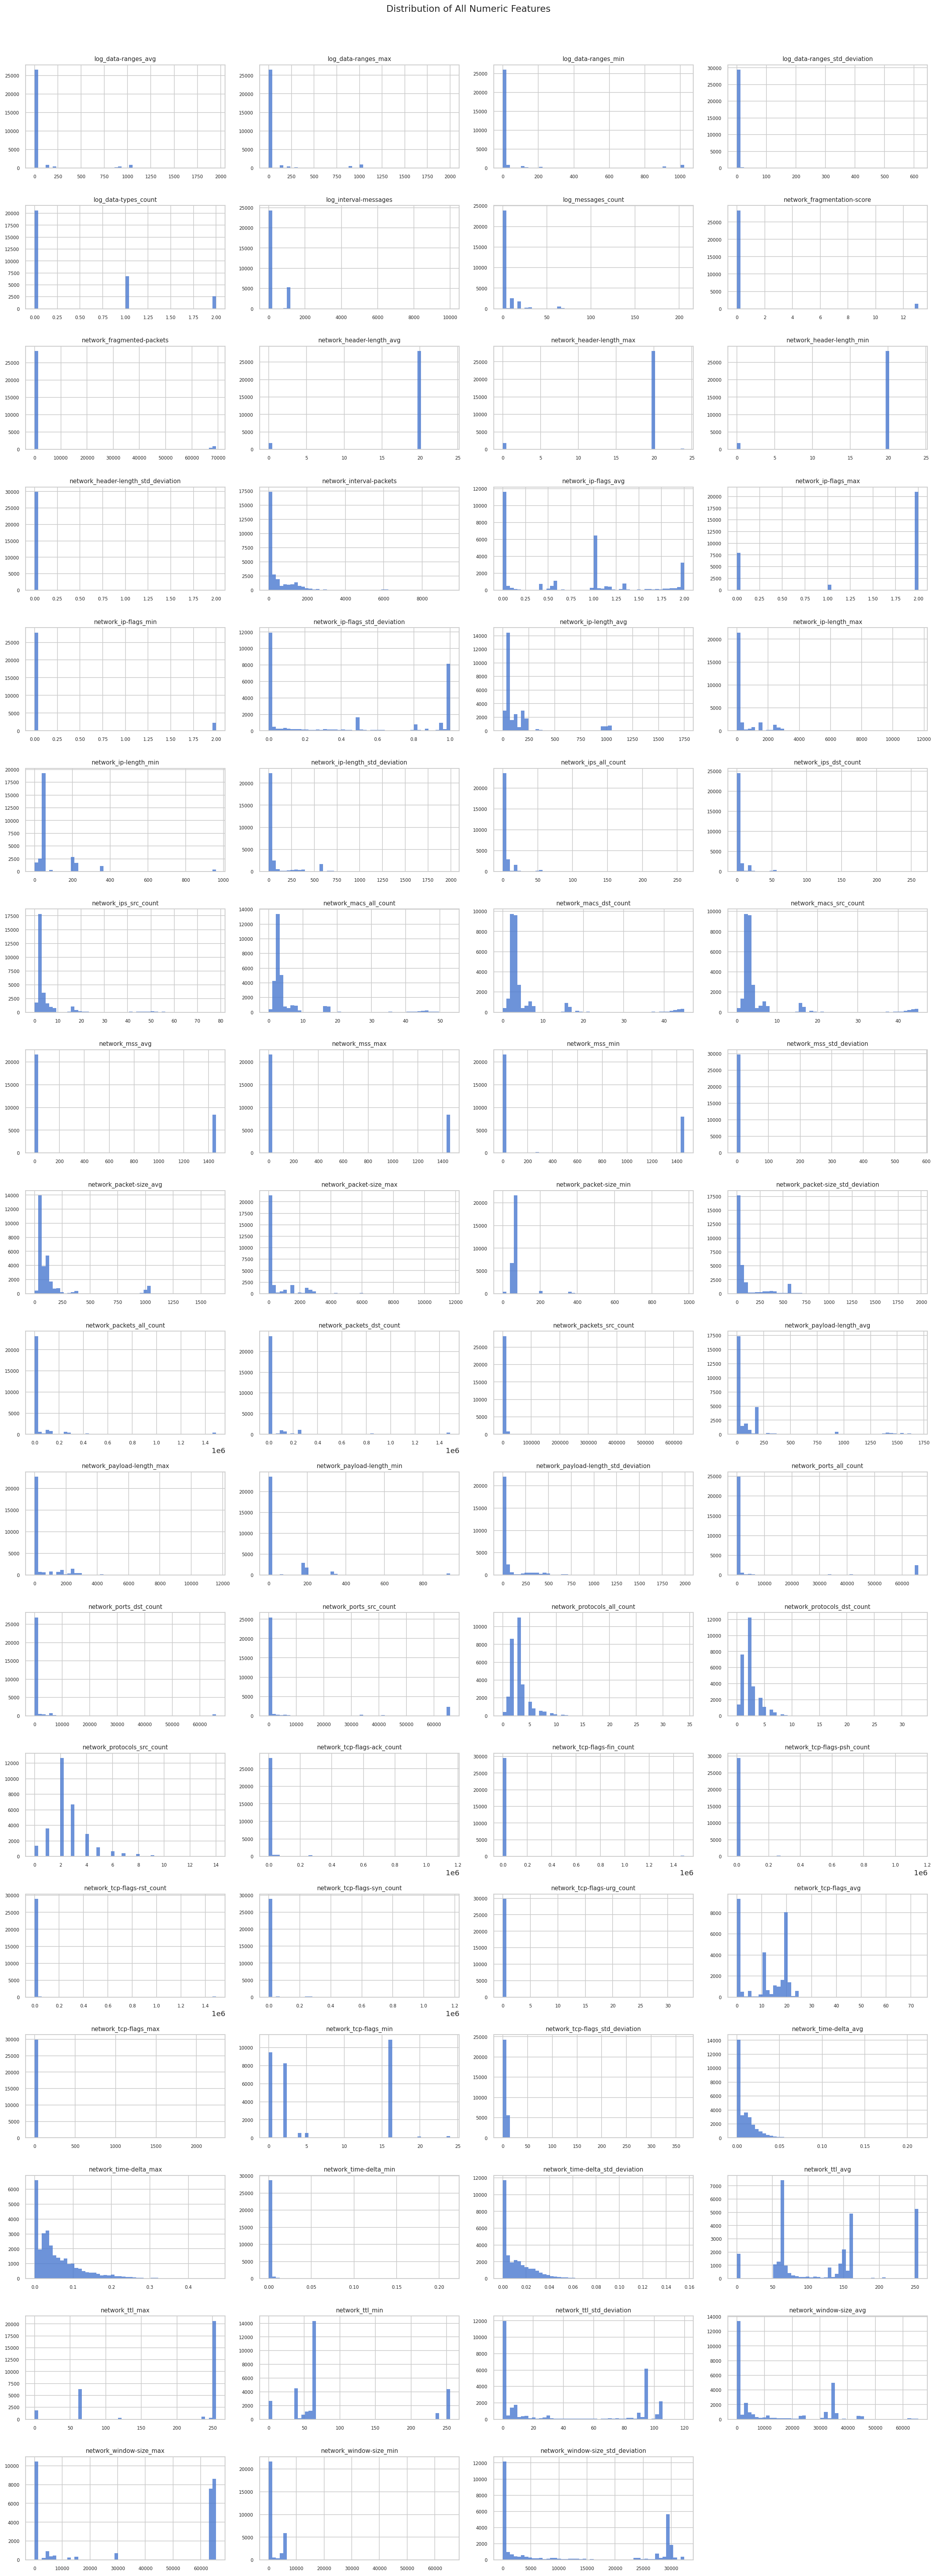

In [10]:
n_numeric = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n_numeric / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor="none", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of All Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../results/eda_feature_distributions.png", bbox_inches="tight")
plt.show()

--- 

## Skewness Analysis

Flag highly skewed features. These may benefit from log or power transforms before feeding into neural network

In [11]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("=== Top 15 Most Positively Skewed Features ===")
print(skewness.head(15).round(2).to_string())
print("\n=== Top 15 Most Negatively Skewed Features ===")
print(skewness.tail(15).round(2).to_string())

highly_skewed = skewness[skewness.abs() > 5]
print(f"\n{len(highly_skewed)} features with |skewness| > 5 (candidates for log transform)")

=== Top 15 Most Positively Skewed Features ===
network_tcp-flags_std_deviation        22.90
network_header-length_std_deviation    21.98
log_data-ranges_std_deviation          21.09
network_tcp-flags-urg_count            19.20
network_mss_std_deviation              18.35
network_tcp-flags_max                  16.39
network_time-delta_min                 15.49
network_window-size_min                10.71
network_tcp-flags-psh_count            10.20
network_tcp-flags-fin_count             9.93
network_tcp-flags-rst_count             9.59
network_tcp-flags-syn_count             9.13
network_tcp-flags-ack_count             8.96
network_packet-size_min                 8.67
network_packets_src_count               8.48

=== Top 15 Most Negatively Skewed Features ===
network_mss_max                      0.97
network_window-size_avg              0.87
network_tcp-flags_min                0.50
network_ip-flags_avg                 0.50
network_ttl_std_deviation            0.44
network_window-size_

---

## Correlation Analysis

A heatmap of pairwise Pearson correlations. Highly correlated features indicate redundancy, motivating the DataSense paper's feature selection. For readability, the top 30 most-varying numeric features are shown.

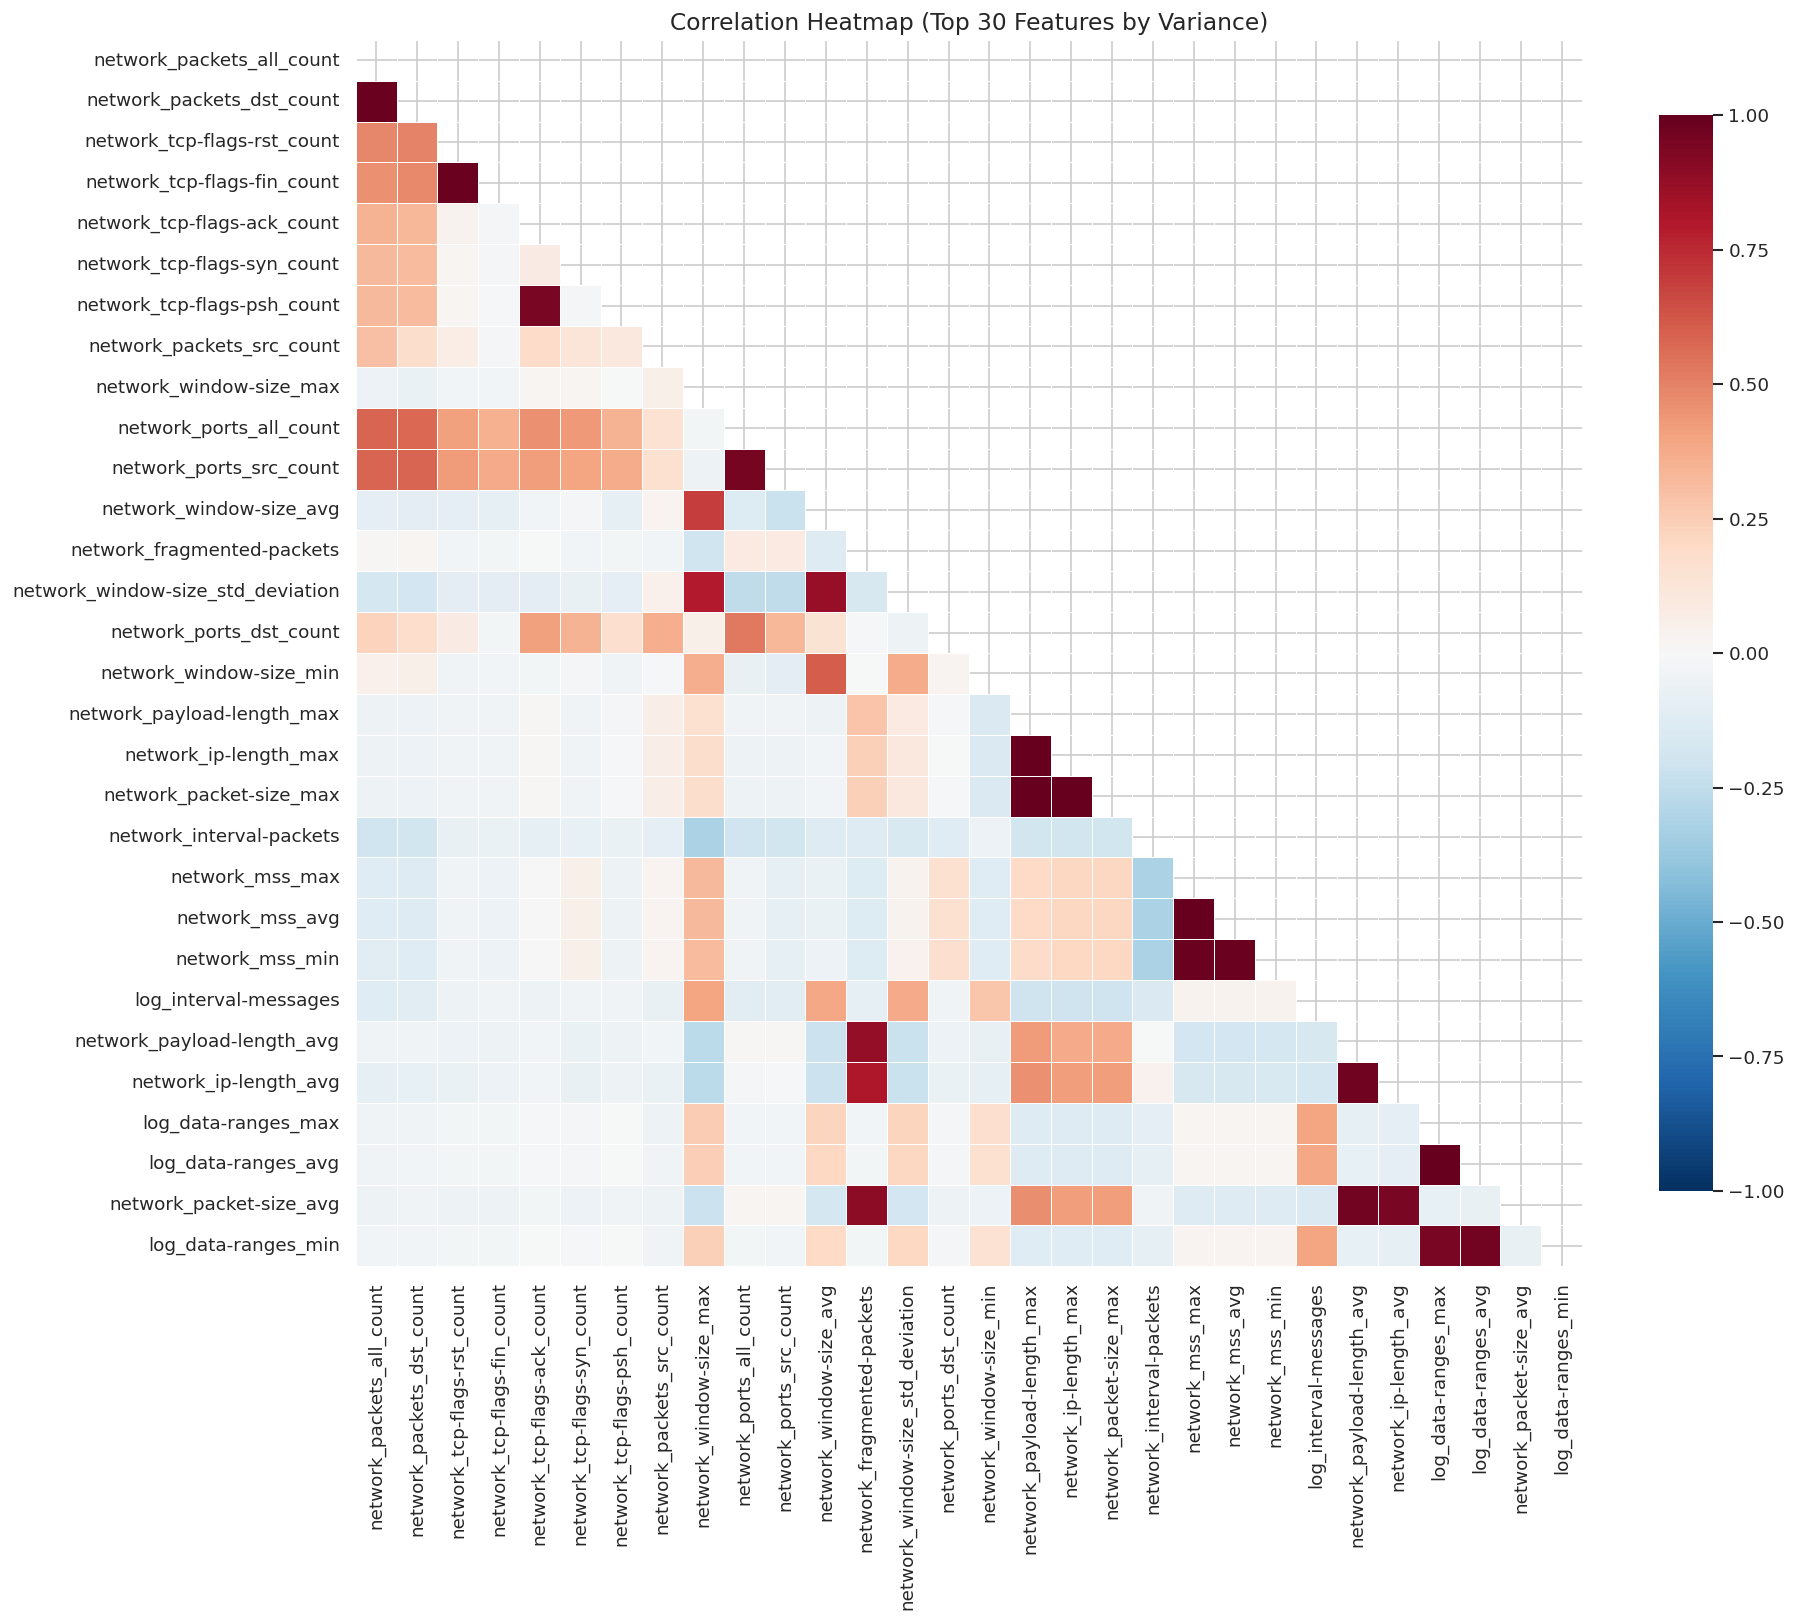

=== Highly Correlated Feature Pairs (|r| > 0.95) ===
  network_mss_max                          ↔ network_mss_avg                           r=1.000
  network_ip-length_max                    ↔ network_packet-size_max                   r=1.000
  network_payload-length_max               ↔ network_ip-length_max                     r=0.998
  network_payload-length_max               ↔ network_packet-size_max                   r=0.997
  log_data-ranges_max                      ↔ log_data-ranges_avg                       r=0.993
  network_packets_all_count                ↔ network_packets_dst_count                 r=0.991
  network_mss_avg                          ↔ network_mss_min                           r=0.989
  network_mss_max                          ↔ network_mss_min                           r=0.988
  network_tcp-flags-rst_count              ↔ network_tcp-flags-fin_count               r=0.986
  network_payload-length_avg               ↔ network_ip-length_avg                     r=0.9

In [12]:
# Use top 30 features by std to keep the heatmap readable
top_varying = df[numeric_cols].std().nlargest(30).index.tolist()
corr_matrix = df[top_varying].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=False, square=True,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap (Top 30 Features by Variance)", fontsize=14)
plt.tight_layout()
plt.savefig("../results/eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Identify highly correlated pairs
print("=== Highly Correlated Feature Pairs (|r| > 0.95) ===")
corr_unstacked = corr_matrix.where(mask == False).unstack().dropna()
high_corr = corr_unstacked[(corr_unstacked.abs() > 0.95) & (corr_unstacked.abs() < 1.0)]
high_corr = high_corr.sort_values(ascending=False)
if len(high_corr) > 0:
    for (f1, f2), r in high_corr.items():
        print(f"  {f1:40s} ↔ {f2:40s}  r={r:.3f}")
else:
    print("  None found.")

---

## The 17 Selected DataSense Features

The DataSense paper's feature selection identified 17 key features (Table 7). These are ideal for the FL model since they keep it lightweight — realistic for edge IIoT devices.

Found 17/17 selected features in the dataframe.


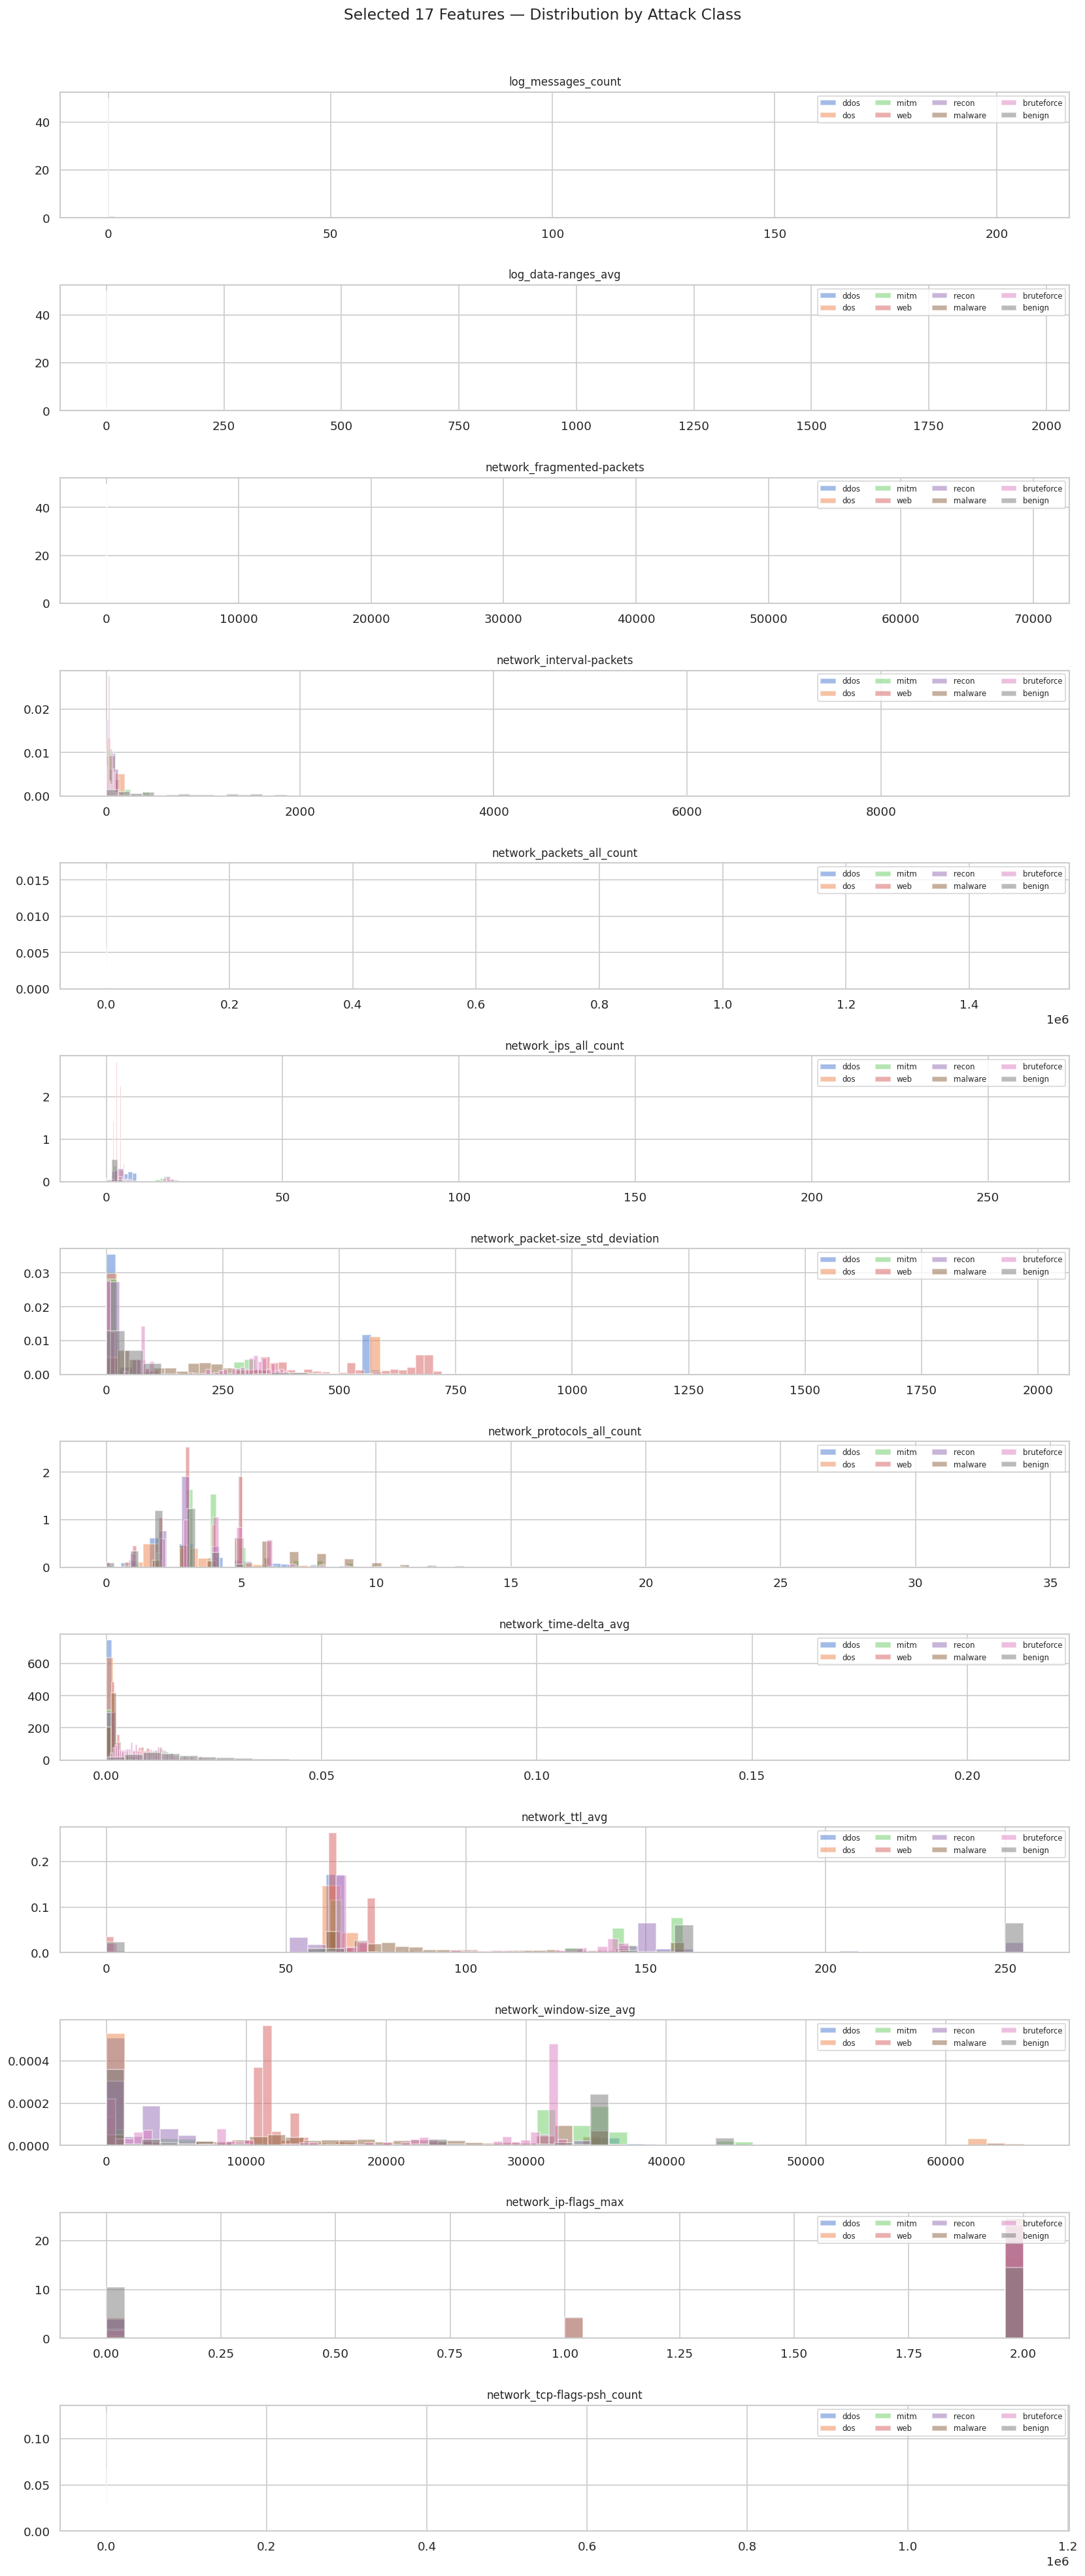

In [13]:
SELECTED_17 = [
    "log_messages_count",
    "log_data-ranges_avg",
    "log_data-types",        # NOTE: this is a list-type/string feature — may need encoding
    "network_fragmented-packets",
    "network_interval-packets",
    "network_packets_all_count",
    "network_ips_dst",                # NOTE: list-type in some versions, count in others
    "network_ips_all_count",
    "network_macs_src",               # NOTE: list-type in some versions
    "network_packet-size_std_deviation",
    "network_ports_all",              # NOTE: list-type
    "network_protocols_all_count",
    "network_time-delta_avg",
    "network_ttl_avg",
    "network_window-size_avg",
    "network_ip-flags_max",
    "network_tcp-flags-psh_count",
]
 
# Check which of these exist in the dataframe
found = [c for c in SELECTED_17 if c in df.columns]
missing_sel = [c for c in SELECTED_17 if c not in df.columns]
 
print(f"Found {len(found)}/17 selected features in the dataframe.")
if missing_sel:
    print(f"Missing or differently named: {missing_sel}")
    print("\n→ Check your CSV headers. Column names may use underscores or different casing.")
    print(f"  Your columns containing 'Message': {[c for c in df.columns if 'essag' in c.lower()]}")
    print(f"  Your columns containing 'Packet':  {[c for c in df.columns if 'acket' in c.lower()]}")
    print(f"  Your columns containing 'IP':      {[c for c in df.columns if 'ip' in c.lower()]}")
 
# If found, show their distributions by class
if len(found) >= 5:
    numeric_selected = [c for c in found if df[c].dtype in [np.float64, np.int64, float, int]]
    
    fig, axes = plt.subplots(len(numeric_selected), 1, figsize=(14, len(numeric_selected) * 2.5))
    if len(numeric_selected) == 1:
        axes = [axes]
    
    for i, col in enumerate(numeric_selected):
        for label in df[LABEL_COL].unique():
            subset = df[df[LABEL_COL] == label][col].dropna()
            axes[i].hist(subset, bins=50, alpha=0.5, label=label, density=True)
        axes[i].set_title(col, fontsize=10)
        axes[i].legend(fontsize=7, ncol=4, loc="upper right")
    
    plt.suptitle("Selected 17 Features — Distribution by Attack Class", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("../results/eda_selected_features_by_class.png", bbox_inches="tight")
    plt.show()

---
## Per-Class Feature Behavior (Box Plots)

Box plots of key features broken out by class. This reveals which features differentiate attack types and which classes overlap.

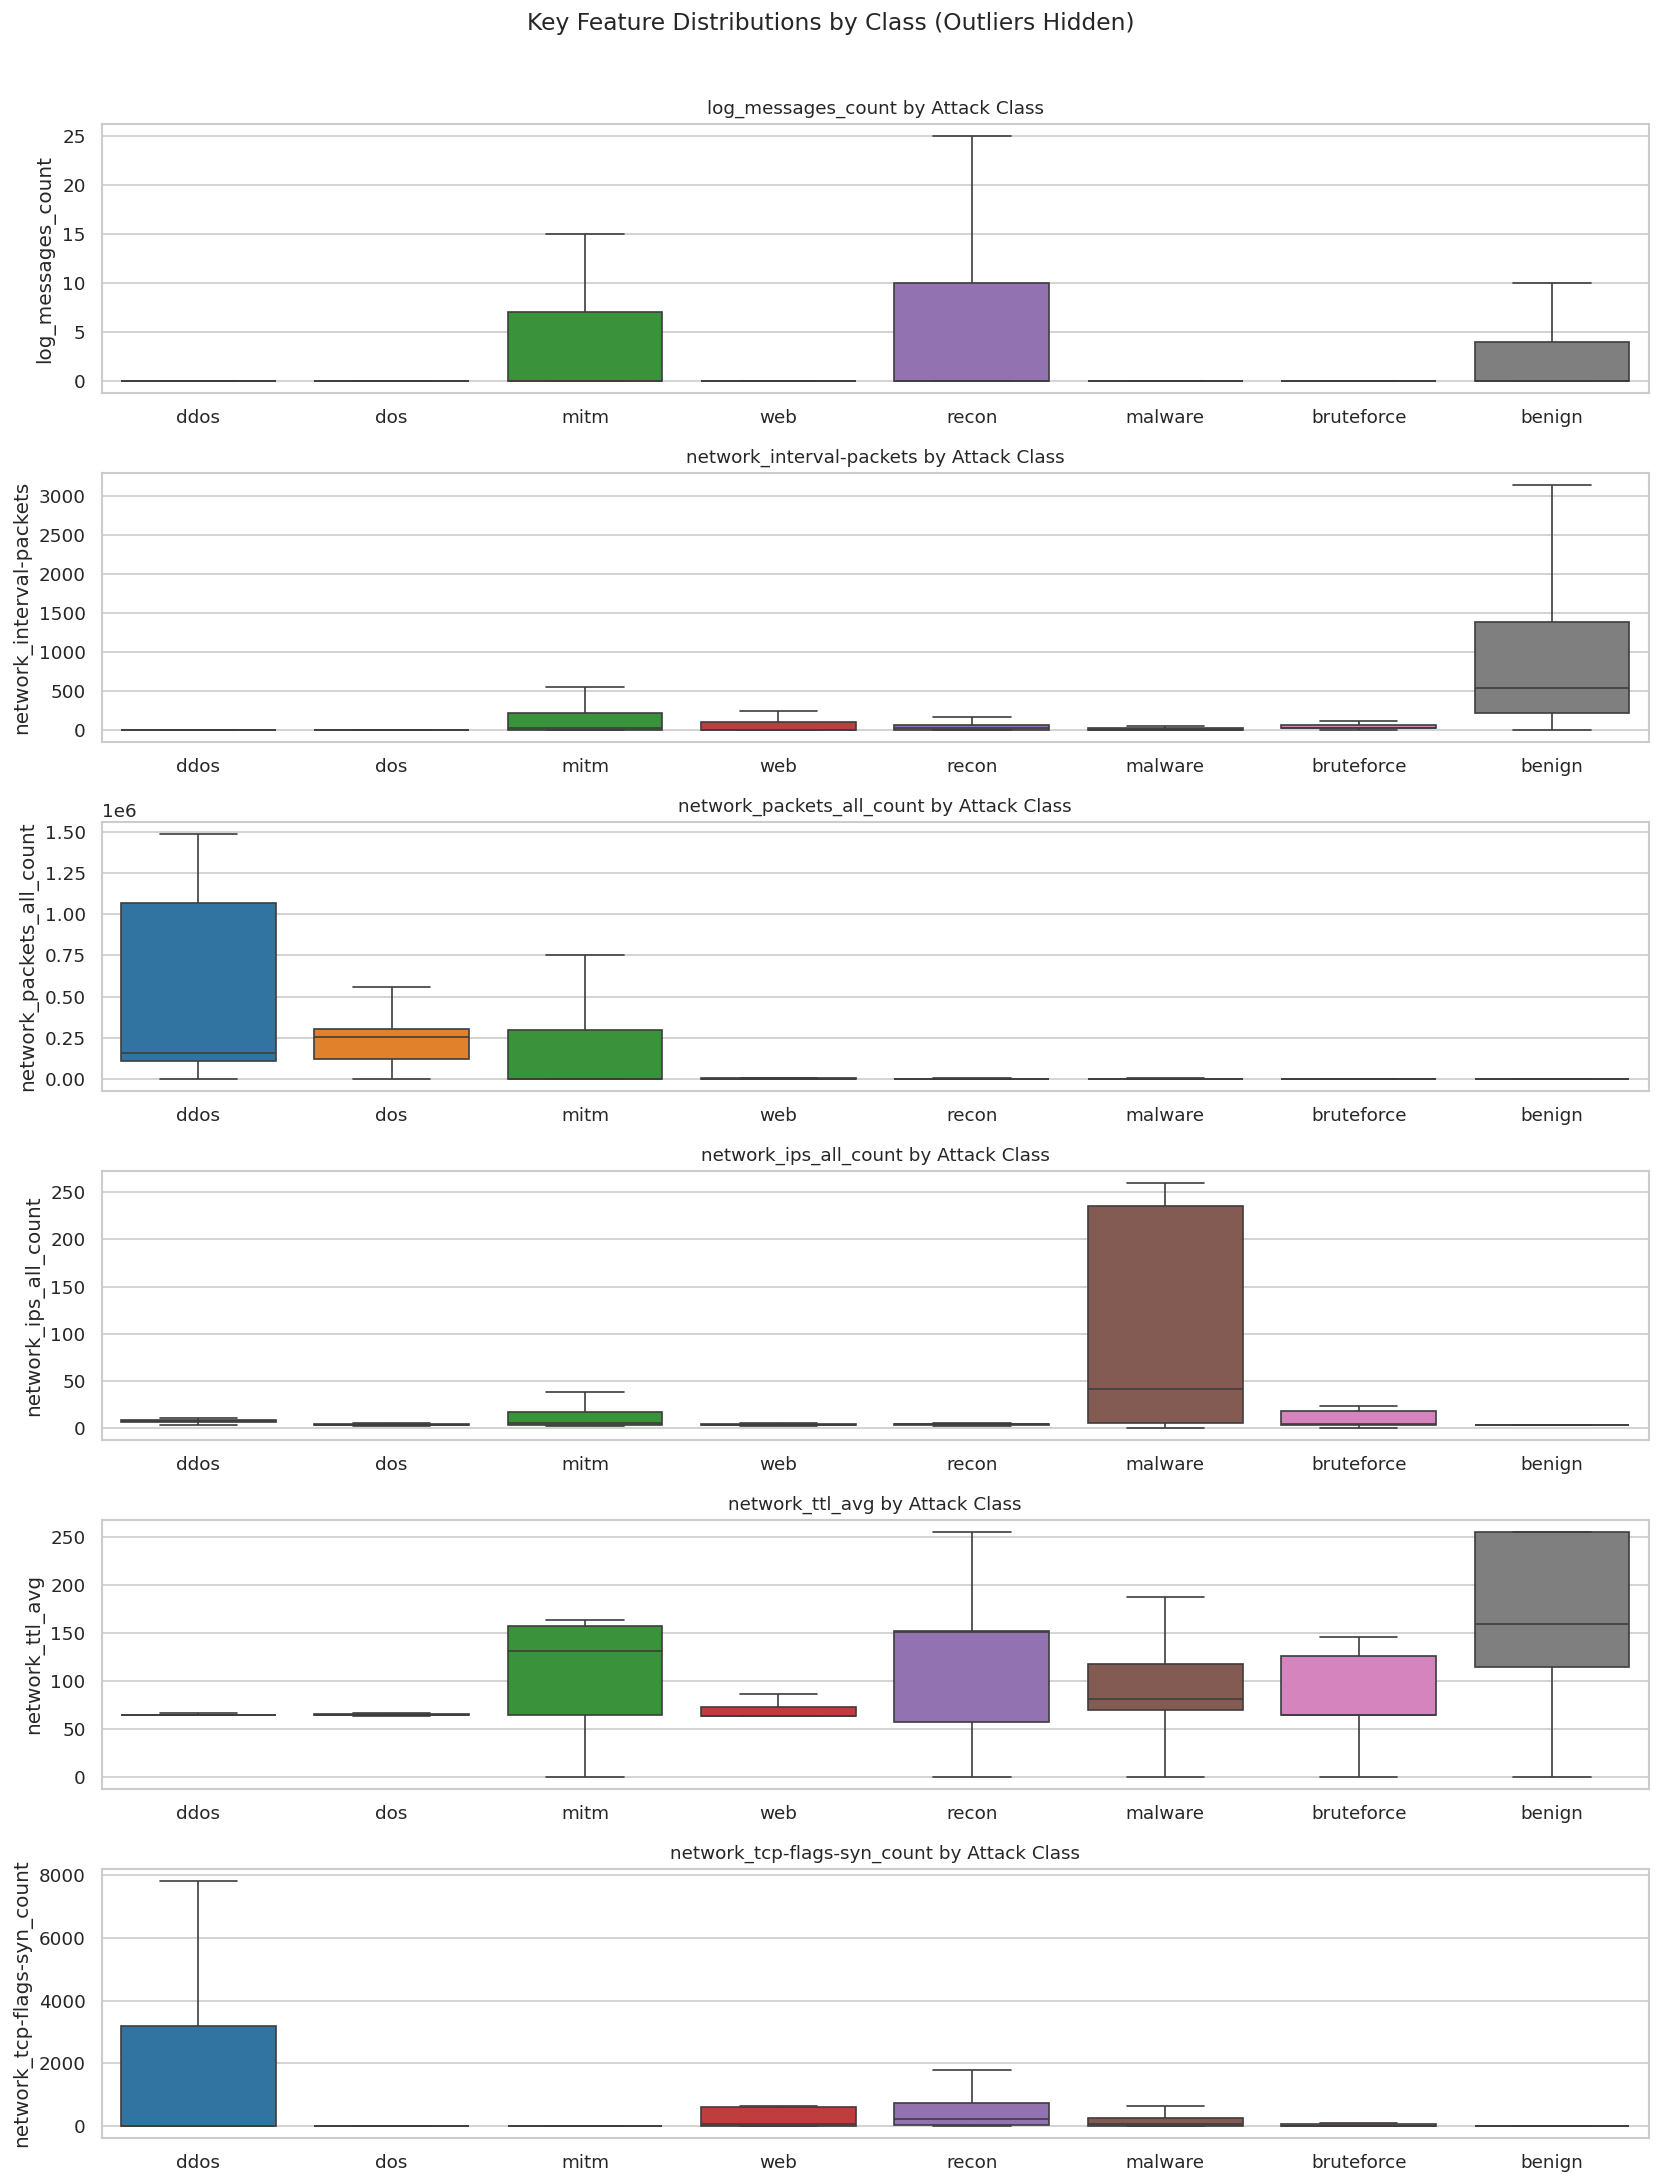

In [15]:
key_features = [
    "log_messages_count",
    "network_interval-packets",
    "network_packets_all_count",           
    "network_ips_all_count",
    "network_ttl_avg",
    "network_tcp-flags-syn_count",
]
key_features = [f for f in key_features if f in df.columns]
 
if key_features:
    fig, axes = plt.subplots(len(key_features), 1, figsize=(14, len(key_features) * 3))
    if len(key_features) == 1:
        axes = [axes]
    
    for i, col in enumerate(key_features):
        sns.boxplot(data=df, x=LABEL_COL, y=col, ax=axes[i],
                    showfliers=False, palette="tab10")
        axes[i].set_title(f"{col} by Attack Class", fontsize=11)
        axes[i].set_xlabel("")
    
    plt.suptitle("Key Feature Distributions by Class (Outliers Hidden)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("../results/eda_boxplots_by_class.png", bbox_inches="tight")
    plt.show()
else:
    print("Could not find key feature columns — update the list above to match your CSV headers.")

---
## Class Separability

Pairwise scatter plots of the most discriminative features, colored by class. This gives a visual sense of how separable the classes are in feature space.

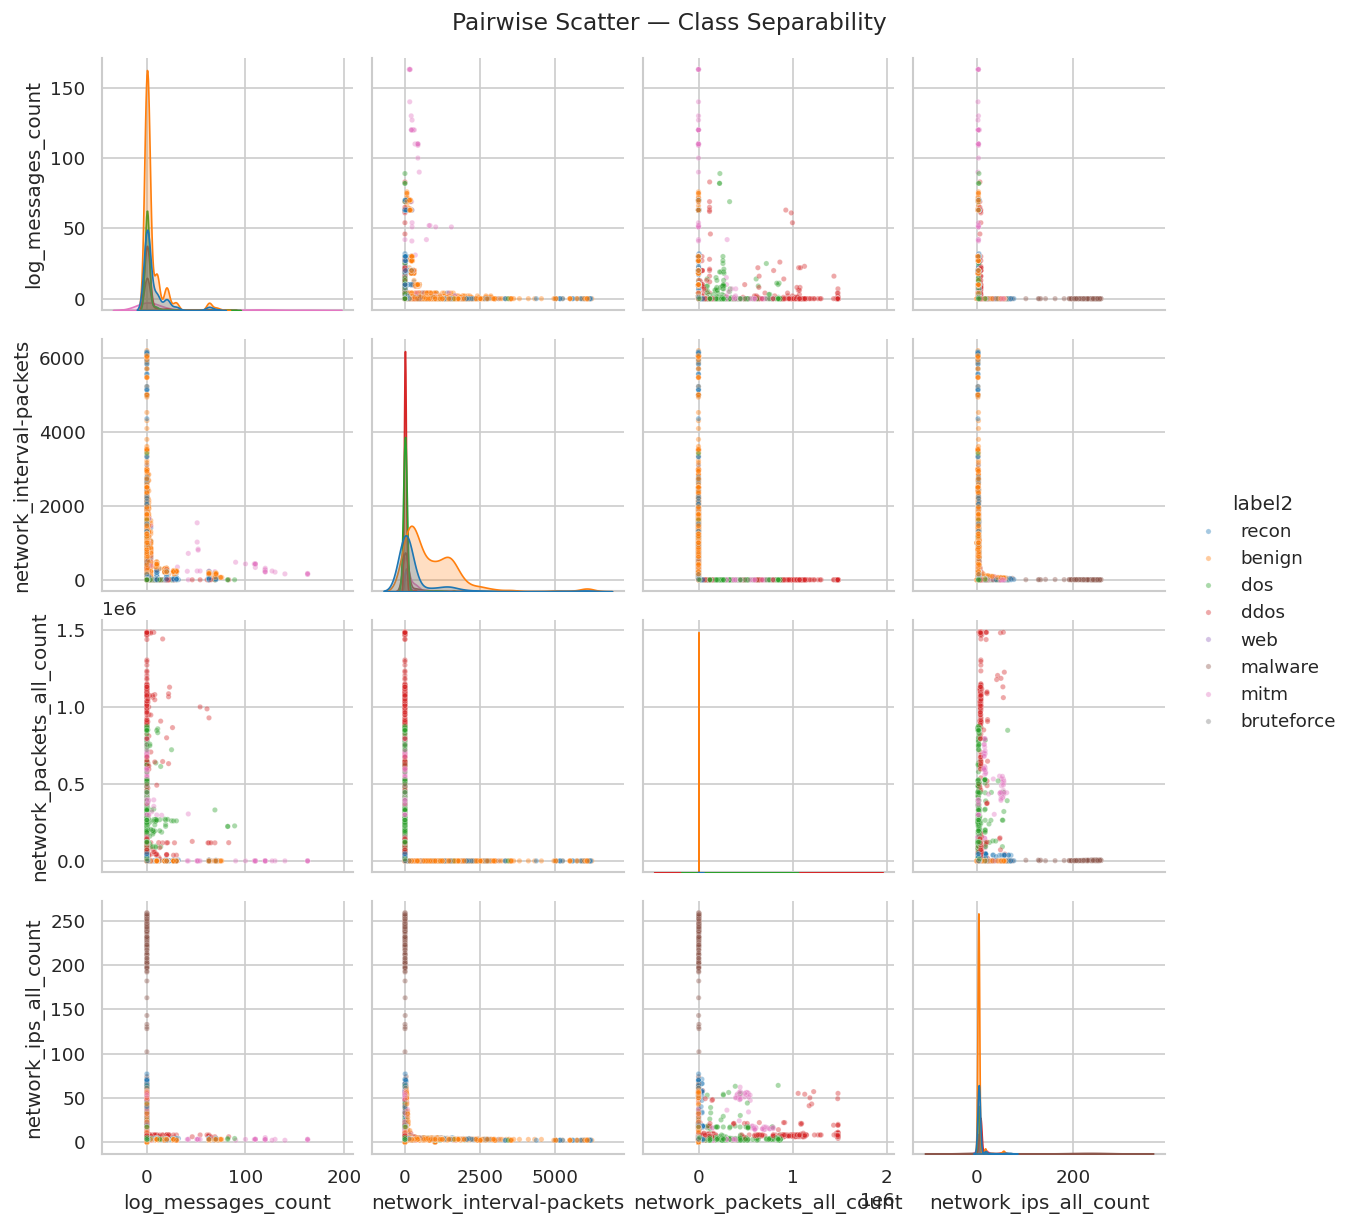

In [17]:
scatter_features = key_features[:4] if len(key_features) >= 4 else key_features
 
if len(scatter_features) >= 2:
    # Subsample for performance if dataset is large
    sample = df.sample(n=min(5000, len(df)), random_state=42)
    
    g = sns.pairplot(
        sample,
        vars=scatter_features,
        hue=LABEL_COL,
        plot_kws={"alpha": 0.4, "s": 10},
        diag_kind="kde",
        palette="tab10",
        height=2.5,
    )
    g.fig.suptitle("Pairwise Scatter — Class Separability", y=1.02, fontsize=14)
    plt.savefig("../results/eda_pairplot.png", bbox_inches="tight")
    plt.show()

---
## Device-Level Patterns

Analyze how samples distribute across devices.


=== Samples per Device ===


device_name
edge1                         2037
mqtt-broker                   2034
router                        1092
ap                             955
wisenet-camera                 923
steam-sensor                   892
weather-sensor                 873
yi-camera                      871
motion-sensor                  870
light-sensor                   822
water-sensor                   822
gas-sensor                     822
accelerometer-sensor           822
ultrasonic-sensor              822
sound-sensor                   822
soil-sensor                    821
proximity-collision-sensor     818
vibration-sensor               815
flame-sensor                   815
rfid-sensor                    812
geeni-camera                   801
myq-camera                     799
blurams-camera                 792
switch                         791
dekco-camera                   786
plug-all-cameras               575
plug-all-rpb                   543
plug-proximity                 524
plug-cam

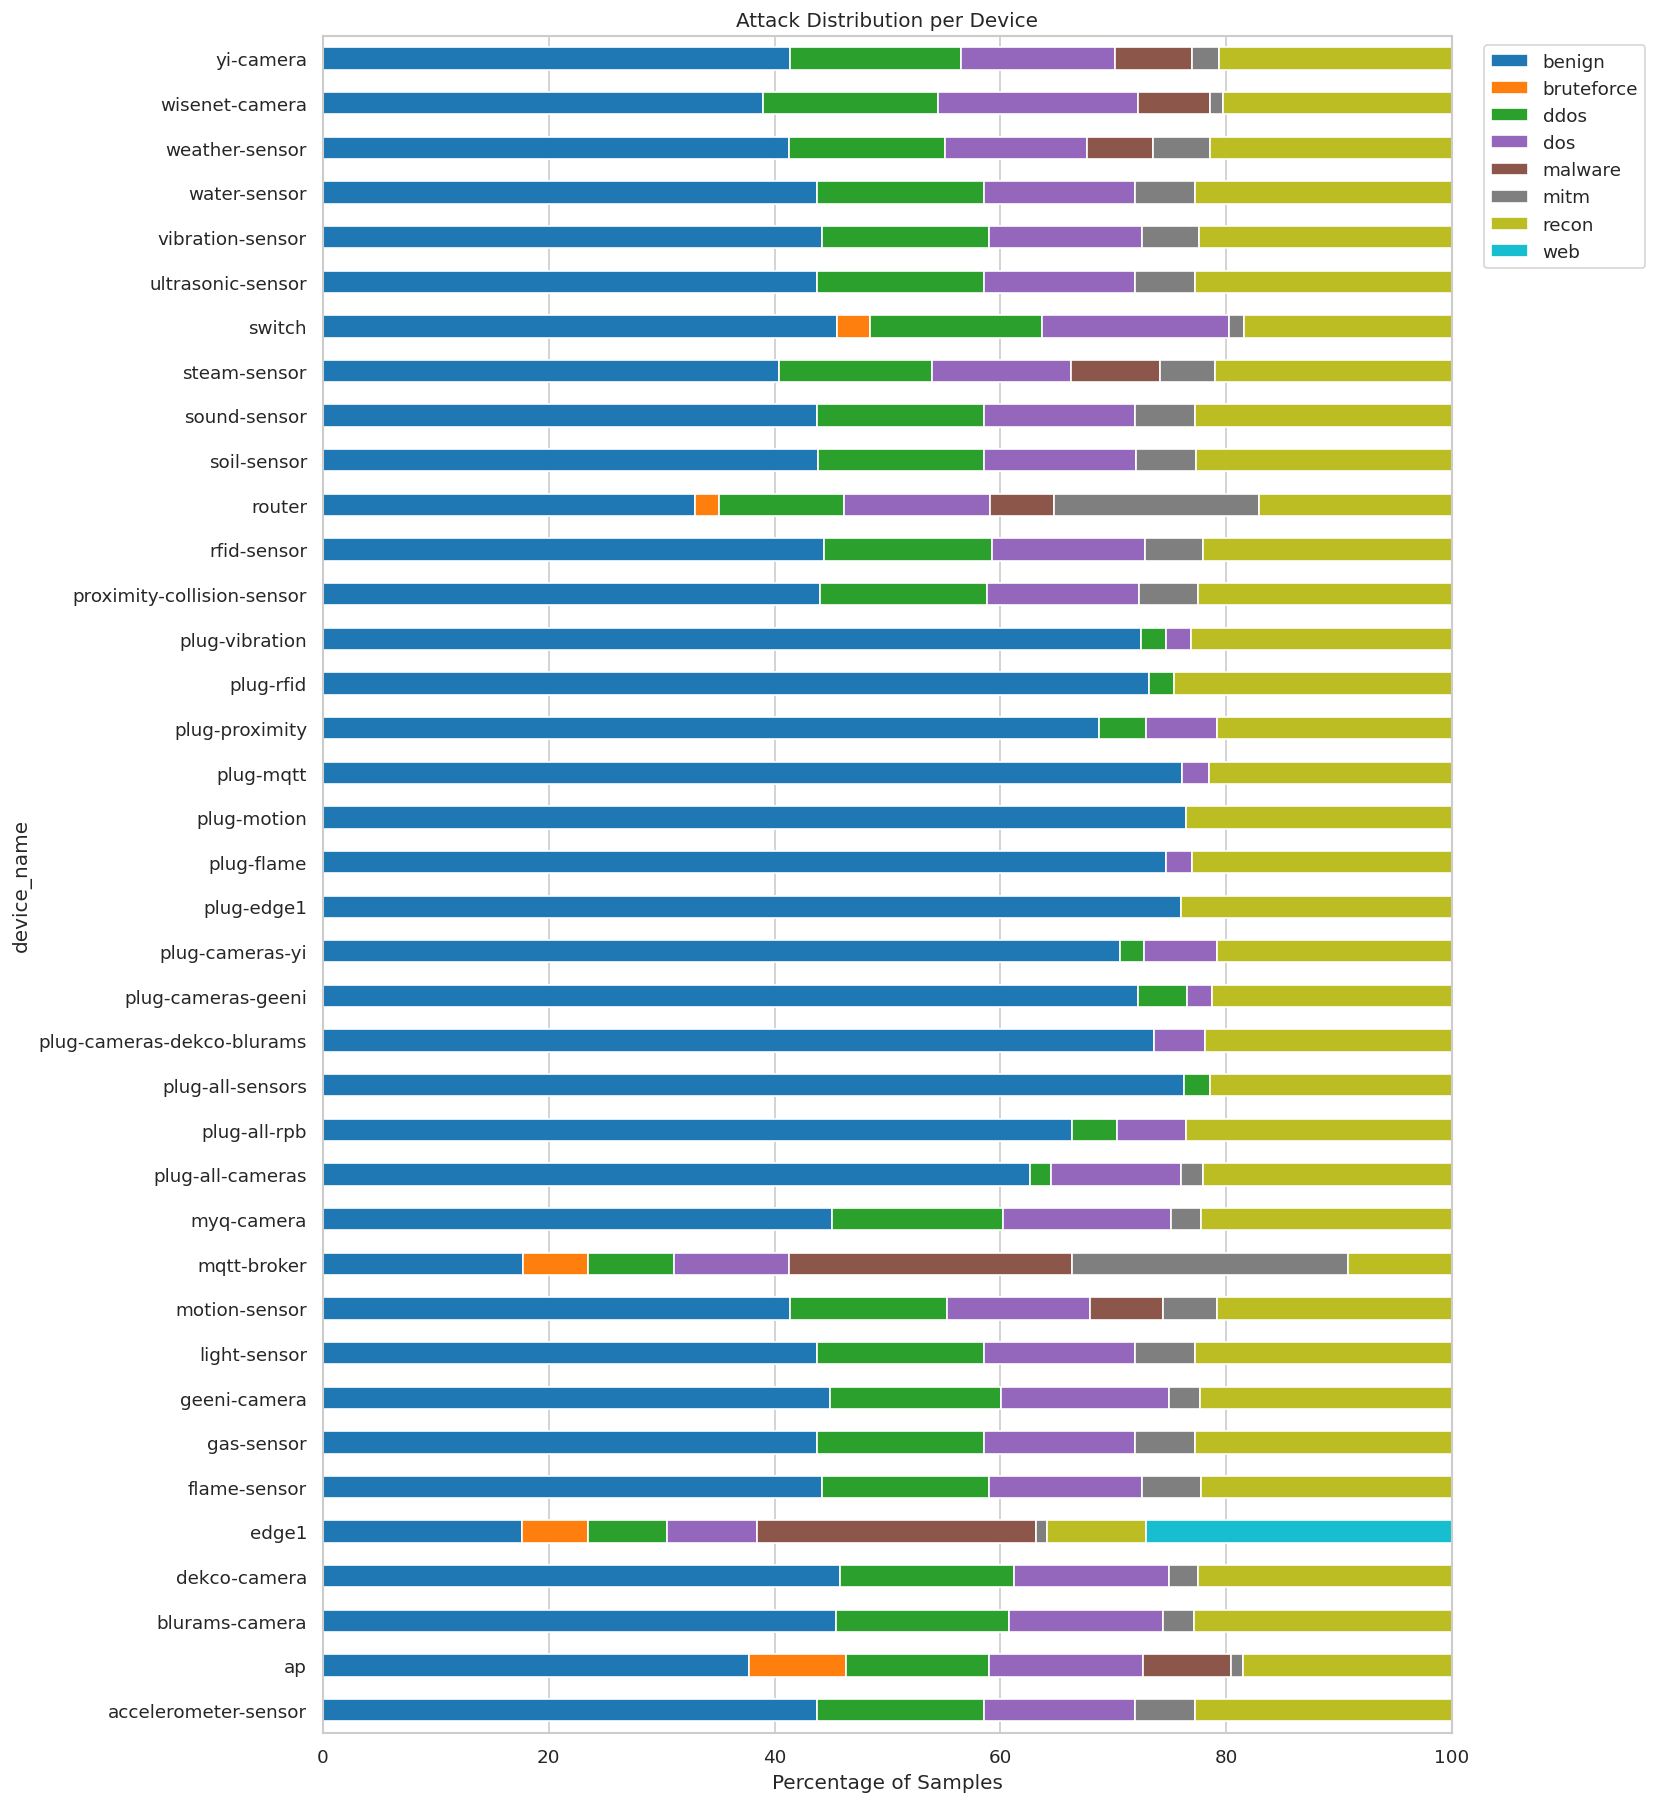

In [19]:
print(f"\n=== Samples per Device ===")
device_counts = df[DEVICE_COL].value_counts()
display(device_counts)

# Device × Attack class cross-tabulation
cross = pd.crosstab(df[DEVICE_COL], df[LABEL_COL], normalize="index") * 100
fig, ax = plt.subplots(figsize=(14, max(6, len(cross) * 0.4)))
cross.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("Percentage of Samples")
ax.set_title("Attack Distribution per Device")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/eda_device_attack_distribution.png", bbox_inches="tight")
plt.show()

---
## List-Type Features



In [20]:
print("=== Object/String Columns — First 3 Values Each ===\n")
for col in object_cols:
    print(f"{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Sample values: {df[col].dropna().head(3).tolist()}")
    print()
 
# Identify which are true list-type features (usually contain commas or brackets)
list_type_cols = []
for col in object_cols:
    sample_val = str(df[col].dropna().iloc[0]) if len(df[col].dropna()) > 0 else ""
    if any(c in sample_val for c in ["[", ",", ";"]):
        list_type_cols.append(col)
 
print(f"\nIdentified list-type columns: {list_type_cols}")
print("→ These should be dropped or converted to counts in preprocessing.py")

=== Object/String Columns — First 3 Values Each ===

device_name:
  Unique values: 38
  Sample values: ['edge1', 'edge1', 'edge1']

device_mac:
  Unique values: 38
  Sample values: ['dc:a6:32:dc:27:d4', 'dc:a6:32:dc:27:d4', 'dc:a6:32:dc:27:d4']

label_full:
  Unique values: 937
  Sample values: ['attack_ddos_syn-flood-port-80_edge1', 'attack_ddos_syn-flood-port-80_edge1', 'attack_ddos_syn-flood-port-80_edge1']

label1:
  Unique values: 2
  Sample values: ['attack', 'attack', 'attack']

label2:
  Unique values: 8
  Sample values: ['ddos', 'ddos', 'ddos']

label3:
  Unique values: 61
  Sample values: ['syn-flood-port-80', 'syn-flood-port-80', 'syn-flood-port-80']

label4:
  Unique values: 84
  Sample values: ['ddos_syn-flood-port-80', 'ddos_syn-flood-port-80', 'ddos_syn-flood-port-80']

timestamp:
  Unique values: 16408
  Sample values: ['2025-01-23T15:31:10.709000Z_2025-01-23T15:31:20.709000Z', '2025-01-23T15:31:15.709000Z_2025-01-23T15:31:25.709000Z', '2025-01-23T15:31:20.709000Z_2025-

---
## Binary Label Check
Verify the binary label split (Benign vs. Attack). This is used for the binary classification task.

In [23]:
binary_counts = df[LABEL_COL_BINARY].value_counts()
print("=== Binary Label Distribution ===")
print(binary_counts)
print(f"\nBenign %: {binary_counts.get('benign', 0) / len(df) * 100:.2f}%")
print(f"Attack %: {binary_counts.get('attack', 0) / len(df) * 100:.2f}%")

=== Binary Label Distribution ===
label1
attack    16350
benign    13680
Name: count, dtype: int64

Benign %: 45.55%
Attack %: 54.45%


---
## Fine-Grained Attack Types

Fine-grained label column: 'label3' (61 unique types)



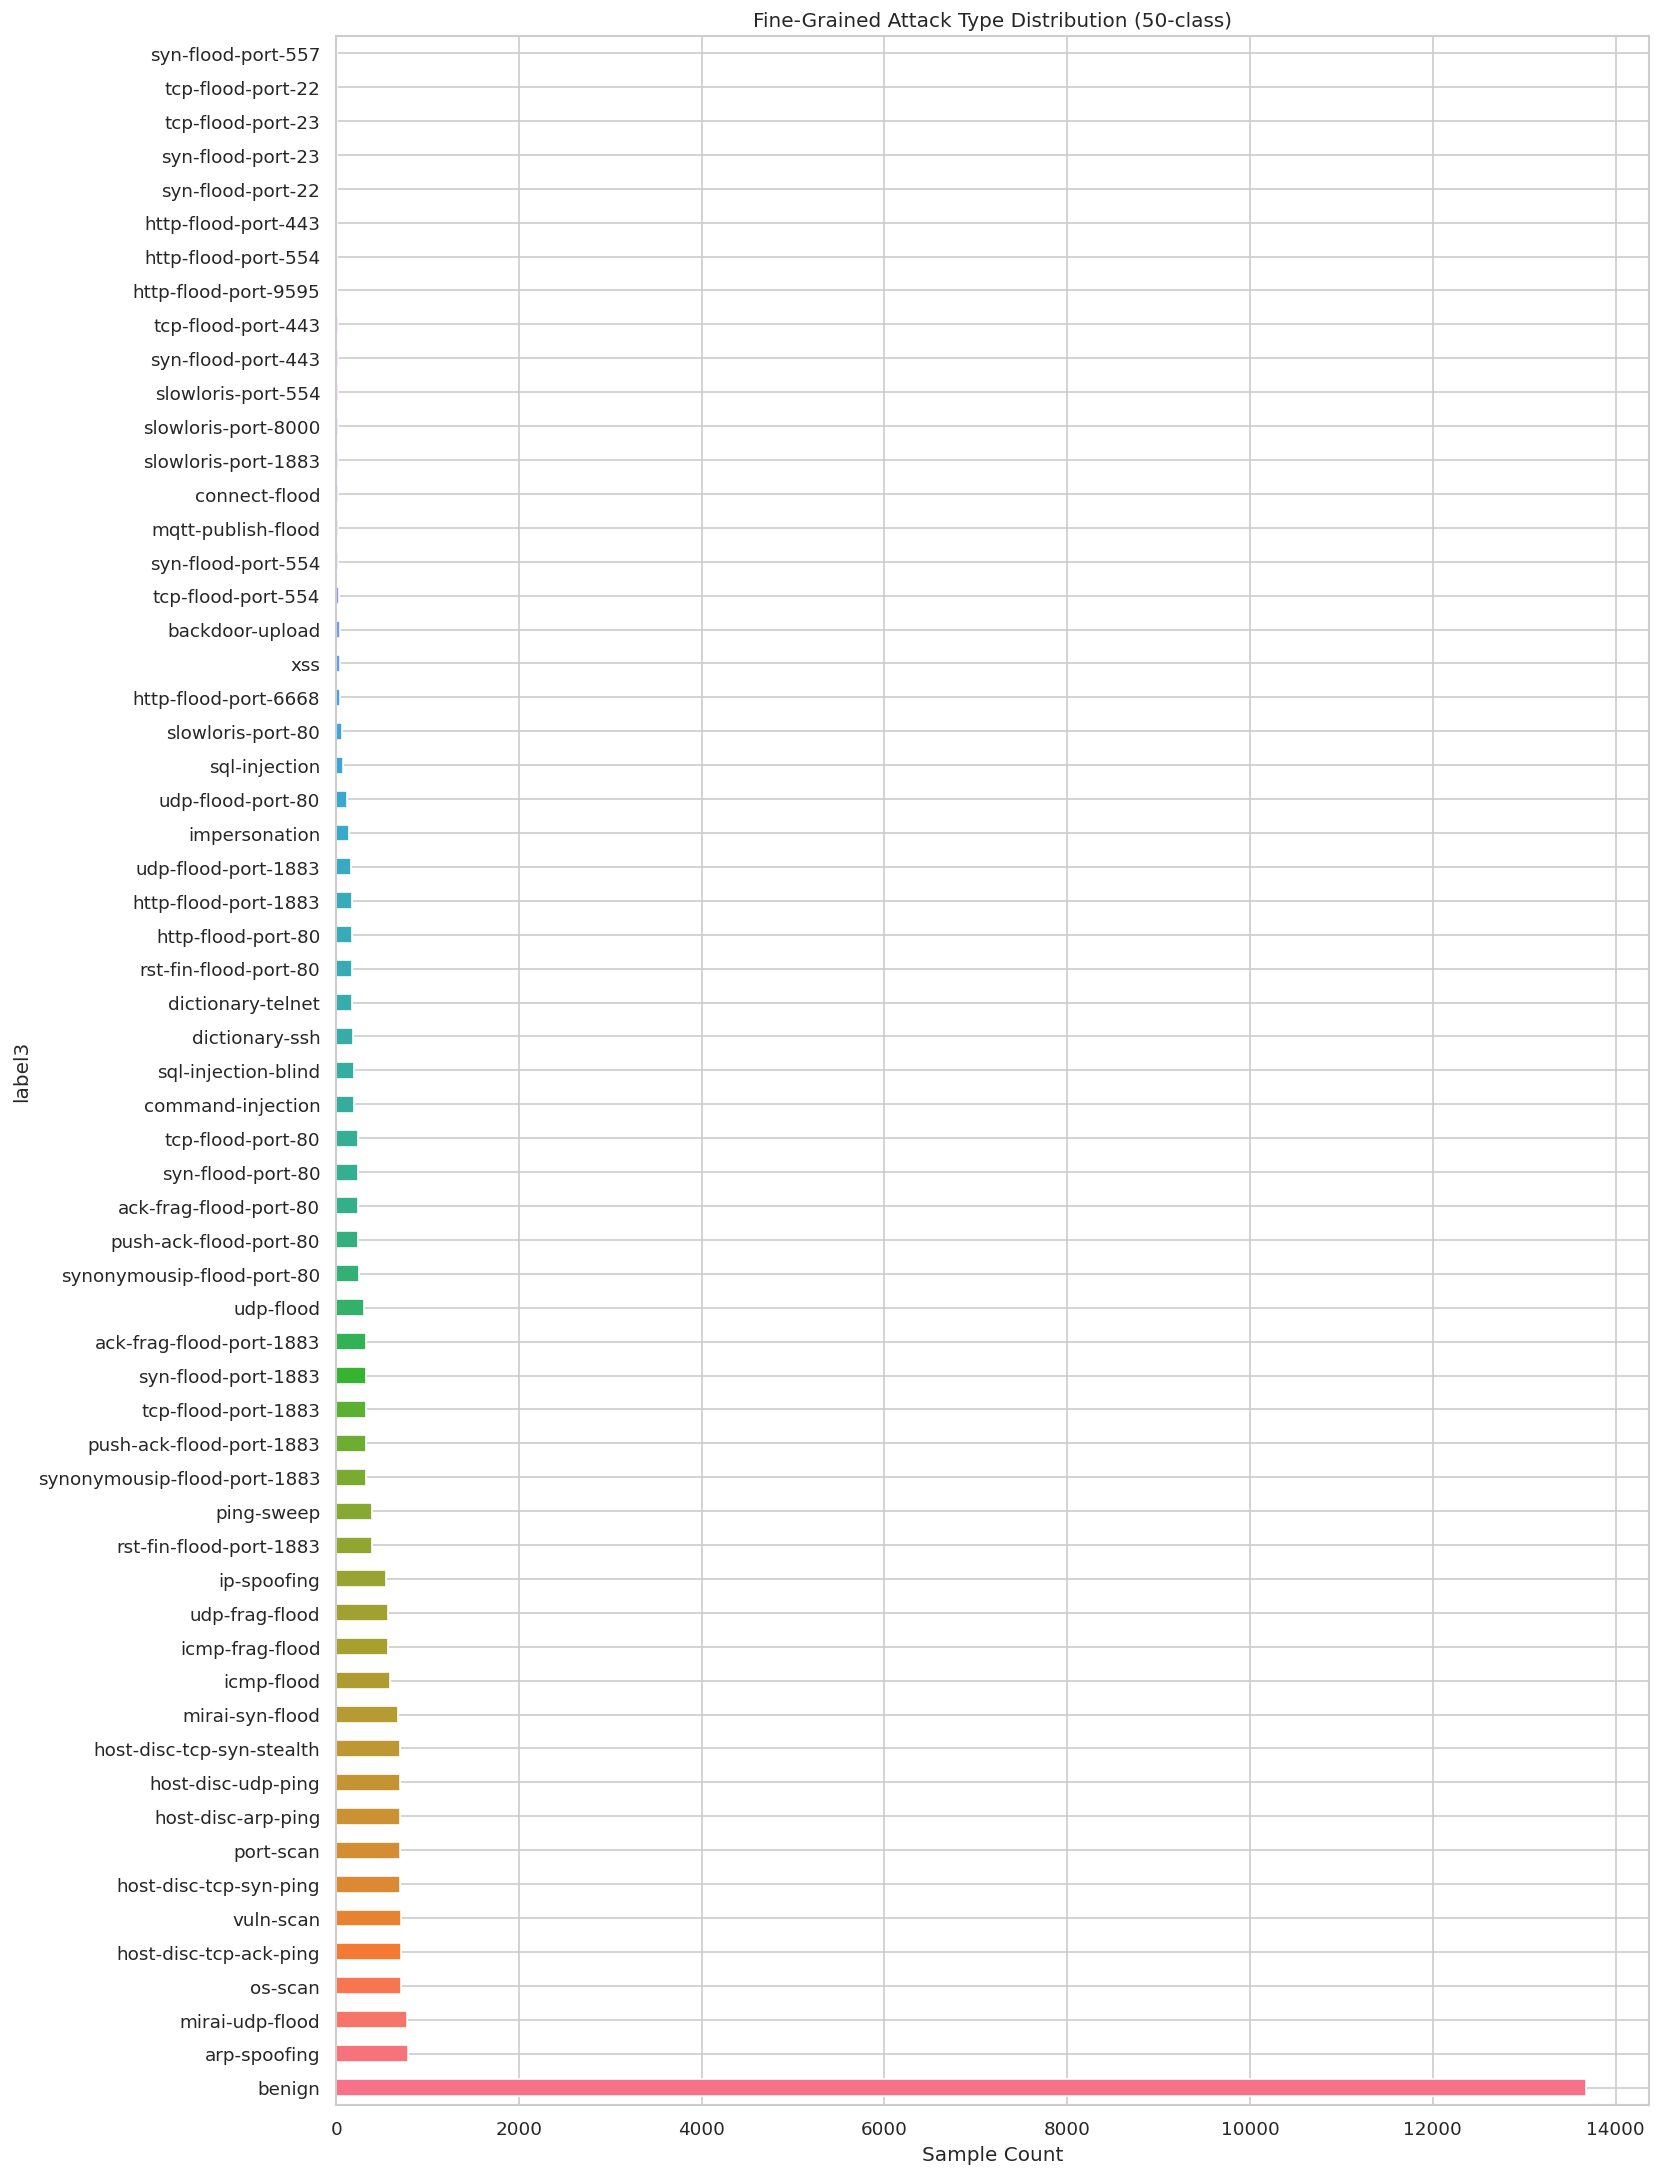

In [24]:
print(f"Fine-grained label column: '{LABEL_COL_FINE}' ({df[LABEL_COL_FINE].nunique()} unique types)\n")
fine_counts = df[LABEL_COL_FINE].value_counts()

fig, ax = plt.subplots(figsize=(14, max(8, len(fine_counts) * 0.3)))
fine_counts.plot(kind="barh", ax=ax, color=sns.color_palette("husl", len(fine_counts)))
ax.set_xlabel("Sample Count")
ax.set_title("Fine-Grained Attack Type Distribution (50-class)")
plt.tight_layout()
plt.savefig("../results/eda_fine_grained_distribution.png", bbox_inches="tight")
plt.show()

---
## Cross-Reference with Metadata Files
Use attacks.csv and devices.csv to validate that the merged dataset contains all expected attack types and devices.

In [ ]:
import os
 
attacks_meta_path = "../data/raw/attacks.csv"   
devices_meta_path = "../data/raw/devices.csv"   
 
if os.path.exists(attacks_meta_path):
    attacks_meta = pd.read_csv(attacks_meta_path)
    print("=== attacks.csv ===")
    print(f"Shape: {attacks_meta.shape}")
    display(attacks_meta.head(10))
    
    # Compare attack categories in metadata vs. dataset
    if "category" in attacks_meta.columns:
        meta_categories = set(attacks_meta["category"].unique())
        print(f"\nAttack categories in metadata: {sorted(meta_categories)}")
        print(f"Attack categories in dataset:  {sorted(actual_classes - {'Benign'})}")
else:
    print(f"attacks.csv not found at {attacks_meta_path} — update the path.")
 
print()
 
if os.path.exists(devices_meta_path):
    devices_meta = pd.read_csv(devices_meta_path)
    print("=== devices.csv ===")
    print(f"Shape: {devices_meta.shape}")
    display(devices_meta.head(10))
    print(f"\nDevice types/roles present: {devices_meta.columns.tolist()}")
else:
    print(f"devices.csv not found at {devices_meta_path} — update the path.")

=== attacks.csv ===
Shape: (1346, 10)


,filename,data_type,category,attack_name,attack_target,doc_count,start,end,start_timestamp,end_timestamp
0,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,edge1,7907037,2025-01-23T15:31:10.709Z,2025-01-23T15:32:12.789Z,1.737646e+12,1.737646e+12
1,attack_ddos_push-ack-flood-port-80_edge1,attack,ddos,push-ack-flood-port-80,edge1,7888985,2025-01-24T20:15:17.562Z,2025-01-24T20:16:19.565Z,1.737750e+12,1.737750e+12
2,attack_ddos_rst-fin-flood-port-1883_light-sensor,attack,ddos,rst-fin-flood-port-1883,light-sensor,7886989,2025-01-25T14:52:26.685Z,2025-01-25T14:53:28.661Z,1.737817e+12,1.737817e+12
3,attack_ddos_rst-fin-flood-port-80_router,attack,ddos,rst-fin-flood-port-80,router,7883402,2025-01-25T15:13:14.519Z,2025-01-25T15:14:16.564Z,1.737818e+12,1.737818e+12
4,attack_ddos_rst-fin-flood-port-80_edge1,attack,ddos,rst-fin-flood-port-80,edge1,7879480,2025-01-25T15:20:10.535Z,2025-01-25T15:21:12.470Z,1.737818e+12,1.737818e+12
5,attack_ddos_rst-fin-flood-port-80_switch,attack,ddos,rst-fin-flood-port-80,switch,7879052,2025-01-25T15:23:38.361Z,2025-01-25T15:24:40.381Z,1.737819e+12,1.737819e+12
6,attack_ddos_udp-flood-port-80_switch,attack,ddos,udp-flood-port-80,switch,7877568,2025-01-23T20:55:16.795Z,2025-01-23T20:56:18.793Z,1.737666e+12,1.737666e+12
7,attack_ddos_rst-fin-flood-port-80_wisenet-camera,attack,ddos,rst-fin-flood-port-80,wisenet-camera,7870773,2025-01-25T15:47:53.896Z,2025-01-25T15:48:55.881Z,1.737820e+12,1.737820e+12
8,attack_ddos_udp-flood-port-80_router,attack,ddos,udp-flood-port-80,router,7870560,2025-01-23T20:47:09.900Z,2025-01-23T20:48:11.908Z,1.737665e+12,1.737665e+12
9,attack_ddos_udp-flood-port-80_yi-camera,attack,ddos,udp-flood-port-80,yi-camera,7870351,2025-01-23T22:45:18.351Z,2025-01-23T22:46:20.355Z,1.737672e+12,1.737672e+12



Attack categories in metadata: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']
Attack categories in dataset:  ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']

=== devices.csv ===
Shape: (45, 6)


,mac,ip,device_name,role,type,main_topic
0,28:87:ba:bd:c6:6c,192.168.1.1,router,router,network,NaN
1,dc:a6:32:dc:28:46,192.168.1.193,mqtt-broker,mqtt-broker,raspberry-pie,NaN
2,dc:a6:32:dc:27:d4,192.168.1.195,edge1,edge,raspberry-pie,NaN
3,e0:46:ee:21:56:18,192.168.1.200,switch,switch,network,NaN
4,30:de:4b:e2:13:4e,192.168.1.205,ap,ap,network,NaN
5,08:b6:1f:82:12:30,192.168.1.10,weather-sensor,sensor,sensor,iiot/weather/temp
6,08:b6:1f:84:66:78,192.168.1.11,water-sensor,sensor,sensor,iiot/water
7,f0:08:d1:ce:cf:0c,192.168.1.12,soil-sensor,sensor,sensor,iiot/soil
8,08:b6:1f:81:d2:cc,192.168.1.13,steam-sensor,sensor,sensor,iiot/steam
9,08:b6:1f:83:25:98,192.168.1.14,gas-sensor,sensor,sensor,iiot/gas/gas



Device types/roles present: ['mac', 'ip', 'device_name', 'role', 'type', 'main_topic']


---
## EDA Summary & Preprocessing Decisions



In [27]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║  EDA SUMMARY                                                     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. DATASET SIZE                                                 ║
║     → Total rows:            30,030                              ║
║     → Total columns:             94                              ║
║     → Numeric features:          71                              ║
║     → Object features:           23                              ║
║                                                                  ║
║  2. LABEL DISTRIBUTION  (label2 — 8-class primary target)        ║
║     → benign:      13,680  (45.55%)  ████████████████████████    ║
║     → recon:        6,005  (20.00%)  ███████████                 ║
║     → dos:          3,280  (10.92%)  ██████                      ║
║     → ddos:         3,234  (10.77%)  ██████                      ║
║     → mitm:         1,471   (4.90%)  ███                         ║
║     → malware:      1,444   (4.81%)  ███                         ║
║     → web:            552   (1.84%)  █                           ║
║     → bruteforce:     364   (1.21%)  █                           ║
║     → Max/min imbalance ratio: 37.6:1  (benign/bruteforce)       ║
║                                                                  ║
║  3. DATA QUALITY                                                 ║
║     → Missing values:              0  ✓ no action needed         ║
║     → Infinite values:             0  ✓ no action needed         ║
║     → Constant columns:            0  ✓ no action needed         ║
║     → Near-zero variance cols:     0  ✓ no action needed         ║
║                                                                  ║
║  4. PREPROCESSING DECISIONS  (for preprocessing.py)              ║
║     a) Drop 13 list-type string cols (raw IPs, MACs, ports,      ║
║        protocols) — count variants already in numeric cols       ║
║     b) Drop 1 from each highly correlated pair  (r ≥ 0.95):      ║
║        e.g. network_mss_avg, network_packet-size_max …           ║
║     c) log1p-transform 18 skewed features  (|skew| > 5):         ║
║        TCP flag counts, std-deviation features                   ║
║     d) StandardScaler on all numerics  (fit on train only)       ║
║     e) LabelEncoder for 8-class target  (label2)                 ║
║     f) Use class weights in loss (inverse-frequency);            ║
║        no oversampling in FL setting                             ║
║     g) 17 selected features for lightweight FL edge model        ║
║     h) Drop non-feature cols: timestamp*, device_mac,            ║
║        label_full, label1, label3, label4                        ║
║                                                                  ║
║  5. FL PARTITIONING IMPLICATIONS                                 ║
║     → 38 devices → partition by device_name  (non-IID)           ║
║     → Per-device distributions vary: rare attack types           ║
║       may be absent on some clients                              ║
║     → devices.csv: roles/types for sector-based splits           ║
║     → Scaler must be fit on each client's local train split      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║  EDA SUMMARY                                                     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. DATASET SIZE                                                 ║
║     → Total rows:            30,030                              ║
║     → Total columns:             94                              ║
║     → Numeric features:          71                              ║
║     → Object features:           23                              ║
║                                                                  ║
║  2. LABEL DISTRIBUTION  (label2 — 8-class primary target)        ║
║     → benign:      13,680  (45.55%)  ████████████████████████    ║
║     → recon:        6,005  (20.00%)  ███████████                 ║
║     → dos:          3,280  (10.92%)  ██████                      ║
║     → ddos:         3,234  (10.